# END-TO-END PIPELINE (Steps 1–5: Prompt to Final Video)

## Pipeline Summary

This pipeline converts a user's idea into a complete AI-generated video.

LangGraph is used to connect and control the different stages of the pipeline.

### Overall Flow

User Input  
↓  
Content Moderation  
↓  
Prompt Enhancement  
↓  
Human Review  
↓  
Script Generation  
↓  
Scene Planning  
↓  
Video Prompt Generation  
↓  
Video Generation  
↓  
Speech Generation  
↓  
Subtitle Generation  
↓  
Video Assembly  
↓  
Final Video

---

### 1. User Input

The user provides the basic requirements for the video:

- A text prompt describing the video.
- Optional words or phrases that must be included.
- An optional reference image.

---

### 2. Content Moderation

The user's input is checked before generation begins.

If the input is safe, the pipeline continues.

If the input is unsafe, the user is asked to modify it.

---

### 3. Prompt Enhancement

The original prompt is expanded into a more detailed description of the requested video.

The enhanced prompt contains information such as:

- Topic
- Objective
- Audience
- Tone
- Visual style
- Video duration
- Key message

This gives the later generation stages clearer instructions.

---

### 4. Human Review

The pipeline pauses so the user can review the enhanced prompt.

The user can approve, edit, or reject the prompt before generation continues.

This is implemented using LangGraph's human-in-the-loop functionality.

---

### 5. Script Generation

After the prompt is approved, the LLM generates the narration script.

The result is stored as a `VideoScript`.

---

### 6. Scene Planning

The script is divided into multiple scenes.

Each scene contains information such as:

- Scene ID
- Narration
- Visual description
- Duration

This determines what should appear during each part of the video.

---

### 7. Video Prompt Generation

A video-generation prompt is created for each scene.

Each prompt describes the visual content that the video generation model should create.

The result is stored as a list of `VideoPrompt` objects.

---

### 8. Video Generation

Each `VideoPrompt` is sent to Google Veo to generate a short video clip.

The pipeline supports:

- Text-to-video generation.
- Image-to-video generation when a reference image is provided.

Because video generation is asynchronous, the pipeline waits for each generation job to finish and then downloads the generated video.

The results are stored as `GenerationResult[]`.

> Note: Google Veo is currently returning a `429 RESOURCE_EXHAUSTED` error for the project. A rate-limit request has been submitted to Google.

---

### 9. Speech Generation

The narration from `VideoScript` is converted into speech using Text-to-Speech (TTS).

The generated narration is saved as an audio file.

The result is stored as a `SpeechResult`, containing information such as:

- Audio file path
- Audio duration
- TTS provider
- Voice

---

### 10. Subtitle Generation

The narration script and generated speech are used to create synchronized subtitles.

The process is:

Narration Script  
↓  
Split into Subtitle Chunks  
↓  
Transcribe Audio with Word Timestamps  
↓  
Match Text with Timestamps  
↓  
Create Subtitle Segments  
↓  
Generate SRT File

The result is stored as a `SubtitleResult`.

---

### 11. Video Assembly

The final stage combines all generated components into one video.

The inputs are:

- `GenerationResult[]` — generated scene videos.
- `SpeechResult` — narration audio.
- `SubtitleResult` — synchronized subtitles.

FFmpeg is used to:

1. Put the scene videos in the correct order.
2. Combine the scene videos.
3. Add the narration audio.
4. Add the subtitles.
5. Export the completed video.

The final result is stored as a `FinalVideoResult`.

The completed video is saved to:

`outputs/final/final_video.mp4`

---

## LangGraph Orchestration

LangGraph controls the complete workflow.

It manages:

- Pipeline state.
- Movement between generation stages.
- Content moderation routing.
- Human-in-the-loop review.
- Data passed between different stages.

The shared `VideoState` stores the outputs produced throughout the pipeline.

---

## Main Pipeline Outputs

The main stages produce:

`VideoPrompt[]`  
↓  
Video Generation  
↓  
`GenerationResult[]`

`VideoScript`  
↓  
Speech Generation  
↓  
`SpeechResult`

`VideoScript + SpeechResult`  
↓  
Subtitle Generation  
↓  
`SubtitleResult`

These outputs are then combined:

`GenerationResult[] + SpeechResult + SubtitleResult`  
↓  
FFmpeg Video Assembly  
↓  
`FinalVideoResult`  
↓  
`final_video.mp4`

---

## Final Result

The complete pipeline transforms a simple user prompt into a finished video containing:

- AI-generated scene videos.
- AI-generated narration.
- Synchronized subtitles.
- A final assembled MP4 video.

The final output is:

`outputs/final/final_video.mp4`

## 1. Setup

### 1.1 Import

In [1]:
# Standard library
import os
import time
import subprocess
from pathlib import Path
from enum import Enum
from typing import Optional
from pprint import pprint
import random

# Environment variables
from dotenv import load_dotenv

# Data validation
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

# LLM (OpenAI moderation, TTS, Whisper, and the LangChain chat model)
from openai import OpenAI
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate

# Google Veo
from google import genai
from google.genai import types

# LangGraph
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

# Notebook display helpers
from IPython.display import Image, display

### 1.2 Load Environment Variables

In [2]:
load_dotenv()

AI_MODEL_API_KEY = os.getenv("AI_MODEL_API_KEY")    # OpenAI: moderation, LLM, TTS, and Whisper
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")        # Google Veo

if not AI_MODEL_API_KEY:
    raise ValueError("AI_MODEL_API_KEY not found in .env")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY not found in .env")

### 1.3 Create Output Directories

In [3]:
OUTPUT_DIR = Path("../outputs")
VIDEO_DIR = OUTPUT_DIR / "video_generation" / "videos"
AUDIO_DIR = OUTPUT_DIR / "speech_generation" / "audio"
SUBTITLE_DIR = OUTPUT_DIR / "subtitles"

for directory in [VIDEO_DIR, AUDIO_DIR, SUBTITLE_DIR]:
    directory.mkdir(parents = True, exist_ok = True)

### 1.4 Pipeline Settings

In [4]:
# Video generation (Notebook 02)
VIDEO_MODEL = "veo-3.1-lite-generate-preview"
# Note: every Veo clip is VIDEO_DURATION_SECONDS long; the planned scene durations are not used.
# In the final video, the narration sets the length: the last frame is held if the scenes are shorter,
# and the video is trimmed if they are longer (nothing is time-stretched).
VIDEO_DURATION_SECONDS = 8
VIDEO_RESOLUTION = "720p"
VIDEO_ASPECT_RATIO = "16:9"

POLL_INTERVAL_SECONDS = 10          # check the asynchronous generation job every 10 seconds.
GENERATION_TIMEOUT_SECONDS = 600    # stop waiting after 10 minutes.

# Veo capacity retry
MAX_RETRY_ATTEMPTS = 6
INITIAL_RETRY_DELAY_SECONDS = 30


# Speech generation (Notebook 03)
TTS_PROVIDER = "openai"
TTS_MODEL = "gpt-4o-mini-tts"
TTS_VOICE = "alloy"
AUDIO_FORMAT = "mp3"

SPEECH_INSTRUCTIONS = ("Speak with a clear, young female voice. "
                        "Use a warm, natural, and friendly tone. "
                        "Speak clearly at a moderate pace with natural pauses. "
                        "Avoid sounding overly dramatic or robotic."
                        )

# Subtitle generation (Notebook 04)
MAX_CHARS_PER_SUBTITLE = 42

ALIGNMENT_PROVIDER = "openai"
ALIGNMENT_MODEL = "whisper-1"

### 1.5 Create API Clients

In [5]:
# OpenAI client used by the moderation nodes (Notebook 01)
moderation_client = OpenAI(api_key = AI_MODEL_API_KEY)

# Google Gen AI client used for Veo (Notebook 02)
client = genai.Client(api_key = GEMINI_API_KEY)

## 2. Shared Models and State

One definition of every model, taken from the notebook that owns it.

### 2.1 Planning Models (Notebook 01)

In [6]:
# ---------------------------------------------------------------------------
# EnhancedPrompt (output schema for LLM)
# ---------------------------------------------------------------------------
class EnhancedPrompt(BaseModel):
    """Structured specification created from the user's original video request."""

    topic: str = Field(description = "The main topic or subject of the video")

    objective: str = Field(description = "What the video should communicate or achieve")

    audience: str = Field(description = "The intended audience for the video")

    tone: str = Field(description = "The desired communication tone")

    visual_style: str = Field(description = "The overall visual style of the video")

    duration_seconds: int = Field(description = "Target duration of the video in seconds")
    
    key_message: str = Field(description = "The main message the viewer should understand")

# ---------------------------------------------------------------------------------------------------------------------------------
# VideoScript (output schema for LLM): you pass the enhanced prompt to the LLM, and the LLM creates the VideoScript
# ---------------------------------------------------------------------------------------------------------------------------------
class VideoScript(BaseModel):
    """Structured narration script for the video."""

    title: str = Field(description = "A short title for the video")

    narration: str = Field(description = "The complete narration script for the video")

# ---------------------------------------------------------------------------
# Scene (output schema for LLM)
# ---------------------------------------------------------------------------
class Scene(BaseModel):
    """Represents one planned scene in the video."""

    scene_id: int = Field(description = "Sequential ID of the scene starting from 1")

    narration: str = Field(description = "The part of the narration spoken during this scene")

    visual_description: str = Field(description = "Description of what should visually happen during this scene")

    # Note: this planned duration is not sent to Veo, and every Veo clip is 8 s long.
    # In the final video (Section 9), the narration sets the length: the last frame is held if the scenes are shorter,
    # and the video is trimmed if they are longer (nothing is time-stretched).
    duration: float = Field(description = "Estimated duration of the scene in seconds")

    continues_previous_scene: bool = Field(description = "True if this scene should visually continue directly from the previous scene using the previous scene's final frame as its starting reference. False if this scene should begin as a new visual shot or setting. Scene 1 must always be False.")

# -------------------------------------------------------------------------------------------------------------------------------------------------
# Scene Plan (output schema for LLM): you pass the script + enhanced prompt to the LLM, and the LLM creates the scenes (including ScenePlan)
# -------------------------------------------------------------------------------------------------------------------------------------------------
class ScenePlan(BaseModel):

    scenes: list[Scene] = Field(description = "Ordered list of scenes for the video")

# --------------------------------------------------------------------------------------------------------
# Video Prompt (output schema for LLM): the instruction for the actual AI video-generation model for one scene.
# --------------------------------------------------------------------------------------------------------

class VideoPrompt(BaseModel):

    scene_id: int = Field(description = "ID of the corresponding scene")
    prompt: str = Field(description = "Detailed prompt for the video-generation model")

# -----------------------------------------------------------------------------------------------------------------------------------
# Video Prompt Plan (output schema for LLM): you pass list[Scene] to the LLM, and the LLM creates list[VideoPrompt]
# -----------------------------------------------------------------------------------------------------------------------------------

class VideoPromptPlan(BaseModel):
    """Structured collection of video-generation prompts."""

    video_prompts: list[VideoPrompt] = Field(description = "Ordered video-generation prompts for all scenes")

### 2.2 Video Generation Models (Notebook 02)

In [7]:
class GenerationStatus(str, Enum):
    """Possible states of a video generation job."""

    PENDING = "pending"
    PROCESSING = "processing"
    COMPLETED = "completed"
    FAILED = "failed"


class VideoGenerationRequest(BaseModel):
    """Request for generating one video scene."""

    scene_id: int = Field(description = "ID of the scene being generated")
    prompt: str = Field(description = "Prompt sent to the video generation model")

    reference_image: Optional[str] = Field(default = None, description = "Optional path to a reference image for image-to-video generation")  # default = None means if the user doesn't provide reference_image, automatically use None.

    duration_seconds: int = Field(default = VIDEO_DURATION_SECONDS, description = "Requested video duration in seconds")

    resolution: str = Field(default = VIDEO_RESOLUTION, description = "Requested video resolution")

    aspect_ratio: str = Field(default = VIDEO_ASPECT_RATIO, description = "Requested video aspect ratio")


class GenerationResult(BaseModel):
    """Result of a video generation job."""

    scene_id: int = Field(description = "ID of the corresponding scene")

    job_id: Optional[str] = Field(default = None, description = "Provider generation job ID")

    status: GenerationStatus = Field(default = GenerationStatus.PENDING, description = "Current generation status")

    video_path: Optional[str] = Field(default = None, description = "Local path of the downloaded video")

    error_message: Optional[str] = Field(default = None, description = "Error message if generation fails")

### 2.3 Speech Models (Notebook 03)

In [8]:
class SpeechRequest(BaseModel):
    """Request for generating speech audio."""

    text: str = Field(description = "Text to convert into speech")

    voice: str = Field(default = TTS_VOICE, description = "Voice used for speech generation")

    audio_format: str = Field(default = AUDIO_FORMAT, description = "Audio output format")


class SpeechResult(BaseModel):
    """Result of speech generation."""

    audio_path: str = Field(description = "Path to the generated audio file")

    duration_seconds: float = Field(description = "Duration of the generated audio in seconds")

    provider: str = Field(description = "TTS provider used")

    voice: str = Field(description = "Voice used for speech generation")

### 2.4 Subtitle Models (Notebook 04)

In [9]:
class SubtitleSegment(BaseModel):
    index: int      # Based on the number of the subtitle segment
    start_time: float
    end_time: float
    text: str


class SubtitleResult(BaseModel):
    subtitle_path: str
    segments: list[SubtitleSegment]
    duration_seconds: float

### 2.5 Video Assembly Model (Step 5)

In [10]:
class FinalVideoResult(BaseModel):
    """The assembled final video."""

    video_path: str = Field(description = "Path to the final MP4 video")

    duration_seconds: float = Field(description = "Duration of the final video in seconds")

    subtitles_burned_in: bool = Field(description = "True if the subtitles are drawn onto the video, False if they are a separate subtitle track")

### 2.6 VideoState

In [11]:
class VideoState(TypedDict, total = False): # total = False means not every key in the TypedDict is required to exist.
    """Shared state passed between nodes in the AgenticVideo LangGraph workflow."""

    # Safety

    is_safe: bool

    moderation_reason: Optional[str]

    # User input

    user_prompt: str                    # user's original request

    required_words: list[str]           # exact words or phrases that must appear

    reference_image: Optional[str]      # path to an uploaded image (provided by the user, to be used as the start of a video clip)

    enhanced_prompt: EnhancedPrompt     # more detailed version of the user's request

    review_action: str                  # "approve" or "edit" again after the user decides to edit the enhanced_prompt

    script: VideoScript                 # narration for the whole video

    scenes: list[Scene]                 # a list of multiple Scene objects

    video_prompts: list[VideoPrompt]    # a list of VideoPrompt objects

    initial_moderation_retry_count: int # counts how many times the user retries because their original input prompt failed moderation

    moderation_retry_count: int         # counts retries after the enhanced prompt has been reviewed/edited

    generation_results: list[GenerationResult]  # one result per scene video clip

    speech_result: SpeechResult                 # narration audio for the whole video

    subtitle_result: SubtitleResult             # timed .srt subtitles for the narration

    final_video: FinalVideoResult               # the assembled final MP4 (Step 5)

## 3. Input Moderation (Notebook 01)

### 3.1 Input Moderation Node

In [12]:
def moderate_input(state: VideoState):
    """Check the user's input before sending it through the video pipeline."""

    moderation_text = state["user_prompt"]

    if state.get("required_words"):
        moderation_text += "\nRequired words: " + ", ".join(state["required_words"])

    response = moderation_client.moderations.create(model = "omni-moderation-latest",
                                                    input = moderation_text
                                                    )

    result = response.results[0]

    retry_count = state.get("initial_moderation_retry_count", 0)

    moderation_reason = None

    if result.flagged:
        retry_count += 1
        moderation_reason = "Input was flagged by the moderation system."

    return {"is_safe": not result.flagged,
            "moderation_reason": moderation_reason,
            "initial_moderation_retry_count": retry_count
            }

### 3.2 Moderation Routing

In [13]:
def route_moderation(state: VideoState):
    """Route based on the original input moderation result."""

    if state["is_safe"]:
        return "enhance_prompt"

    if state.get("initial_moderation_retry_count", 0) >= 3:
        return "end"

    return "review_unsafe_input"

## 4. Prompt Enhancement and Human Review (Notebook 01)

### 4.1 Prompt Enhancement Chain

In [14]:
enhancement_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a prompt enhancement component for an AI video generation system.

Your task is to convert the user's rough video request into a clear and detailed video specification.

Instructions:
- Preserve the user's original intent.
- Do not introduce unrelated ideas.
- Infer reasonable details when information is missing.
- Make the specification suitable for generating a short video.
- Consider any required words or phrases as mandatory requirements.
- Consider the reference image when one is provided.
- Do not write the video script.
"""
    ),
    (
        "human",
        """
User prompt: {user_prompt}

Required words or phrases: {required_words}

Reference image: {reference_image}
"""
    )
])

In [15]:
# Model configuration
ai_model_provider = "openai"
ai_model_name = "gpt-5-mini"
ai_model_api_key = AI_MODEL_API_KEY

# Initialize the LLM
model = init_chat_model(model = ai_model_name,
                        model_provider = ai_model_provider,
                        api_key = ai_model_api_key,
                        temperature = 0
                        )

# Create a version of the model that returns an EnhancedPrompt object
structured_model = model.with_structured_output(EnhancedPrompt)

# Prompt → LLM → EnhancedPrompt
prompt_enhancement_chain = enhancement_prompt | structured_model

### 4.2 Prompt Enhancement Node

In [16]:
def enhance_prompt(state: VideoState):
    """Convert the user's rough prompt into a structured video specification."""

    enhanced_prompt = prompt_enhancement_chain.invoke({"user_prompt": state["user_prompt"],
                                                       "required_words": state.get("required_words", []),
                                                       "reference_image": state.get("reference_image")
                                                       })

    return {"enhanced_prompt": enhanced_prompt}

### 4.3 Review Unsafe Input

In [17]:
def review_unsafe_input(state: VideoState):
    """Allow the user to revise an unsafe input."""

    review = interrupt({"message": ("Your input was flagged. Please revise it before continuing."),
                        "user_prompt": state["user_prompt"],
                        "moderation_reason": state["moderation_reason"],
                        "attempt": state["initial_moderation_retry_count"]
                        })

    action = review.get("action")

    if action == "edit":
        return {"user_prompt": review["user_prompt"], "review_action": "edit"}

    if action == "reject":
        return {"review_action": "reject"}

    raise ValueError("Action must be 'edit' or 'reject'.")

In [18]:
def route_unsafe_input_review(state: VideoState):
    """Route after reviewing an unsafe input."""

    if state["review_action"] == "edit":
        return "moderate_input"

    return "end"

### 4.4 Review Enhanced Prompt

In [19]:
def review_prompt(state: VideoState):
    """Pause the workflow and allow the user to review the enhanced prompt."""

    review = interrupt({"message": "Review the enhanced prompt before script generation.",
                        "enhanced_prompt": state["enhanced_prompt"].model_dump()
                        })

    action = review.get("action")

    if action == "approve":
        return {"review_action": "approve"}

    if action == "edit":
        edited_prompt = EnhancedPrompt.model_validate(review["enhanced_prompt"])
        return {"enhanced_prompt": edited_prompt, "review_action": "edit"}

    if action == "reject":
        return {"review_action": "reject"}

    raise ValueError("Review action must be 'approve', 'edit', or 'reject'.")

In [20]:
# route_review() decides which node LangGraph should execute next after the user reviews the enhanced prompt.

def route_review(state: VideoState):
    """Route based on the human review action."""

    if state["review_action"] == "edit":
        return "moderate_edited_prompt"         # tell LangGraph to go to the moderate_edited_prompt function next

    if state["review_action"] == "reject":
        return "end"                            # user rejects the enhanced_prompt after having a look at the review prompt

    return "generate_script"                    # tell LangGraph to go to the generate_script function next

### 4.5 Moderate the Edited Prompt

In [21]:
def moderate_edited_prompt(state: VideoState):
    """Moderate the human-edited enhanced prompt."""

    moderation_text = str(state["enhanced_prompt"].model_dump())

    response = moderation_client.moderations.create(model = "omni-moderation-latest",
                                                    input = moderation_text
                                                    )

    result = response.results[0]

    moderation_retry_count = state.get("moderation_retry_count", 0)
    moderation_reason = None

    if result.flagged:
        moderation_retry_count += 1
        moderation_reason = "Edited prompt was flagged by the moderation system."

    return {"is_safe": not result.flagged,
            "moderation_reason": moderation_reason,
            "moderation_retry_count": moderation_retry_count
            }

In [22]:
def route_edited_moderation(state: VideoState):
    """Route after moderating the edited prompt."""

    if state["is_safe"]:
        return "review_prompt"

    if state.get("moderation_retry_count", 0) >= 3:
        return "end"

    return "review_prompt"

## 5. Script, Scene, and Video Prompt Generation (Notebook 01)

### 5.1 Script Generation

In [23]:
# Create the instructions that tell the LLM how to turn the approved EnhancedPrompt into narration.

script_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the script generation component of an AI video generation system.

Your task is to write a narration script based on the provided video specification.

Instructions:
- Follow the enhanced video specification closely.
- Write natural spoken narration suitable for the intended audience.
- Keep the tone consistent with the specification.
- Target approximately 1 minute of spoken narration.
- Aim for approximately 130 to 150 words for a 60-second video.
- Include all required words or phrases naturally and exactly as provided.
- Create a clear beginning, middle, and ending.
- Focus only on narration.
- Do not include scene descriptions, camera directions, timestamps, or production instructions.
"""
    ),
    (
        "human",
        """
Enhanced video specification:
{enhanced_prompt}

Required words or phrases:
{required_words}
"""
    )
])

In [24]:
structured_script_model = model.with_structured_output(VideoScript)

script_generation_chain = script_prompt | structured_script_model

In [25]:
def generate_script(state: VideoState):
    """Generate the narration script from the enhanced video specification."""

    script = script_generation_chain.invoke({"enhanced_prompt": state["enhanced_prompt"].model_dump(),
                                             "required_words": state.get("required_words", [])
                                             })

    return {"script": script}

### 5.2 Scene Planning

In [26]:
scene_planning_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the scene planning component of an AI video generation system.

Your task is to divide the narration script into a sequence of visual scenes.

Instructions:
- Create approximately 6 to 10 scenes.
- Keep the scenes in the same order as the narration.
- Each scene must contain the narration spoken during that scene.
- Do not rewrite or add new narration. Split the provided narration across the scenes.
- Give each scene a clear visual description that matches its narration.
- Keep the visual style consistent with the enhanced video specification.
- Estimate the duration of each scene in seconds.
- The total duration of all scenes should approximately match the target video duration.
- Scene IDs must start at 1 and increase sequentially.
- Do not include camera or video-generation details unless they are necessary to explain the visual content.
"""
    ),
    (
        "human",
        """
Enhanced video specification:
{enhanced_prompt}

Video title:
{title}

Narration:
{narration}

Target duration:
{duration_seconds} seconds
"""
    )
])

In [27]:
structured_scene_model = model.with_structured_output(ScenePlan)

scene_planning_chain = scene_planning_prompt | structured_scene_model

In [28]:
def plan_scenes(state: VideoState):
    """Split the narration script into a structured sequence of scenes."""

    scene_plan = scene_planning_chain.invoke({"enhanced_prompt": state["enhanced_prompt"].model_dump(),
                                              "title": state["script"].title,
                                              "narration": state["script"].narration,
                                              "duration_seconds": state["enhanced_prompt"].duration_seconds
                                              })

    return {"scenes": scene_plan.scenes}

### 5.3 Video Prompt Generation

In [29]:
video_prompt_template = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the video prompt generation component of an AI video generation system.

Your task is to convert each planned scene into a detailed prompt for a video-generation model.

Instructions:
- Create exactly one video-generation prompt for each scene.
- Preserve the scene ID.
- Follow the visual description of each scene closely.
- Keep the overall visual style consistent with the enhanced video specification.
- Describe the subject, environment, action, composition, lighting, and visual mood when relevant.
- Include useful camera framing or camera movement when appropriate.
- Make each prompt specific and visually descriptive.
- Maintain visual continuity between scenes.
- Do not change or add narration.
- Do not include subtitle instructions.
- Do not rely on the video model to render required text accurately.
- Do not generate spoken dialogue or narration.
- Background music and ambient environmental sounds are allowed.
- Use background music that matches the mood and visual style of the scene.
- Keep the background audio suitable for mixing with separate narration.
"""
    ),
    (
        "human",
        """
Enhanced video specification:
{enhanced_prompt}

Scenes:
{scenes}
"""
    )
])

In [30]:
structured_video_prompt_model = model.with_structured_output(VideoPromptPlan)

video_prompt_generation_chain = (video_prompt_template | structured_video_prompt_model)

In [31]:
def generate_video_prompts(state: VideoState):
    """Generate a video-generation prompt for each planned scene."""

    scenes = []

    for scene in state["scenes"]:
        scenes.append(scene.model_dump())

    video_prompt_plan = video_prompt_generation_chain.invoke({"enhanced_prompt": state["enhanced_prompt"].model_dump(),
                                                              "scenes": scenes
                                                              })

    return {"video_prompts": video_prompt_plan.video_prompts}

## 6. Video Generation (Notebook 02)

### 6.1 Submit Text-to-Video and Image-to-Video Jobs

In [32]:
def validate_reference_image(image_path: str) -> Path:
    """Validate that the reference image exists and is a supported image file."""

    path = Path(image_path)

    if not path.exists():
        raise FileNotFoundError(f"Reference image not found: {path}")

    if path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        raise ValueError("Reference image must be JPG, JPEG, or PNG.")

    return path

In [33]:
def prepare_reference_image(image_path: str) -> types.Image:
    """Load a local image in the format required by Veo."""

    path = validate_reference_image(image_path)

    image = types.Image.from_file(location = str(path))

    return image

In [34]:
def submit_image_to_video(request: VideoGenerationRequest):
    """Submit an image-to-video generation request to Veo."""

    if request.reference_image is None:
        raise ValueError("reference_image is required for image-to-video generation.")

    reference_image = prepare_reference_image(request.reference_image)

    operation = client.models.generate_videos(model = VIDEO_MODEL,
                                              prompt = request.prompt,
                                              image = reference_image,
                                              config = types.GenerateVideosConfig(duration_seconds = request.duration_seconds,
                                                                                  resolution = request.resolution,
                                                                                  aspect_ratio = request.aspect_ratio
                                                                                  ))

    return operation

In [35]:
def submit_text_to_video(request: VideoGenerationRequest):
    """Submit a text-to-video generation request to Veo."""

    return client.models.generate_videos(model = VIDEO_MODEL,
                                        prompt = request.prompt,
                                        config = types.GenerateVideosConfig(duration_seconds = request.duration_seconds,
                                                                            resolution = request.resolution,
                                                                            aspect_ratio=request.aspect_ratio,
                                                                            )
                                        )

In [36]:
def generate_video(request: VideoGenerationRequest):
    """Submit a video generation request with retry for Veo capacity errors."""

    for attempt in range(MAX_RETRY_ATTEMPTS):
        try:
            if request.reference_image:
                return submit_image_to_video(request)

            return submit_text_to_video(request)

        except Exception as error:
            # Only retry Veo capacity errors
            if "RESOURCE_EXHAUSTED" not in str(error):
                raise

            # Stop after the final attempt
            if attempt == MAX_RETRY_ATTEMPTS - 1:
                raise

            # Exponential backoff with jitter
            wait_seconds = (INITIAL_RETRY_DELAY_SECONDS * (2 ** attempt) + random.uniform(0, 5))

            print(f"Veo capacity unavailable. "
                    f"Retrying in {wait_seconds:.1f} seconds..."
                    )

            time.sleep(wait_seconds)

### 6.2 Poll and Validate Generation

In [37]:
def poll_generation(operation):
    """Poll a Veo generation operation every POLL_INTERVAL_SECONDS until it completes."""

    start_time = time.time()

    while not operation.done:  # Stop if generation takes too long
        if time.time() - start_time > GENERATION_TIMEOUT_SECONDS:
            raise TimeoutError("Video generation timed out.")

        print("Video is still generating...")

        time.sleep(POLL_INTERVAL_SECONDS)

        operation = client.operations.get(operation)

    return operation

In [38]:
# Return the video clip once the status of the job changes to operation.done

def validate_completed_generation(operation):
    """Validate that the completed operation contains a generated video."""

    if not operation.done:  # operation.done is a property of the Veo generation operation
        raise ValueError("Generation operation is not complete.")

    if operation.response is None:
        raise RuntimeError("Generation completed without a response.")

    if not operation.response.generated_videos:
        raise RuntimeError("Generation completed without a generated video.")

    return operation.response.generated_videos[0]

In [39]:
# Purpose: Keep polling Google and get the returned video once operation.done

def wait_for_generation(operation):
    """Wait for a Veo generation job and return the generated video."""

    operation = poll_generation(operation)

    generated_video = validate_completed_generation(operation)

    return operation, generated_video

### 6.3 Download Generated Video

In [40]:
def build_video_output_path(scene_id: int) -> Path:
    """Create the local output path for a generated scene."""

    return VIDEO_DIR / f"scene_{scene_id:03d}.mp4"

In [41]:
def download_generated_video(generated_video, output_path: Path) -> Path:
    """Download a generated Veo video to the local output directory."""

    client.files.download(file = generated_video.video, destination = str(output_path))

    return output_path

In [42]:
def validate_video_file(video_path: Path) -> None:
    """Check that the downloaded video exists."""

    if not video_path.exists():
        raise FileNotFoundError(f"Downloaded video was not found: {video_path}")

    if video_path.stat().st_size == 0:
        raise ValueError(f"Downloaded video is empty: {video_path}")

In [43]:
def save_generated_video(generated_video, result: GenerationResult) -> GenerationResult:
    """Download, validate, and record a completed generated video."""

    output_path = build_video_output_path(result.scene_id)      # build the path

    download_generated_video(generated_video, output_path)      # download video

    validate_video_file(output_path)                            # validate if the video exists

    result.status = GenerationStatus.COMPLETED                  # change the GenerationStatus
    result.video_path = str(output_path)

    return result

### 6.4 Generate All Scenes

In [44]:
def build_generation_request(video_prompt, reference_image: Optional[str] = None) -> VideoGenerationRequest:
    """Convert a VideoPrompt into a video generation request."""

    # Note: every clip uses VIDEO_DURATION_SECONDS (8 s), not the planned scene duration.
    return VideoGenerationRequest(scene_id = video_prompt.scene_id,
                                  prompt = video_prompt.prompt,
                                  reference_image = reference_image,
                                  duration_seconds = VIDEO_DURATION_SECONDS,
                                  resolution = VIDEO_RESOLUTION,
                                  aspect_ratio = VIDEO_ASPECT_RATIO
                                  )

In [45]:
def generate_scene(video_prompt: VideoPrompt, reference_image: Optional[str] = None) -> GenerationResult:

    request = build_generation_request(video_prompt, reference_image = reference_image)

    operation = generate_video(request)

    operation, generated_video = wait_for_generation(operation)

    result = GenerationResult(scene_id = video_prompt.scene_id,
                                status = GenerationStatus.PROCESSING
                            )

    return save_generated_video(generated_video, result)

In [46]:
def generate_all_scenes(video_prompts: list[VideoPrompt], reference_image: Optional[str] = None) -> list[GenerationResult]:
    """Generate video clips for all scenes."""

    results = []

    for index, video_prompt in enumerate(video_prompts):
        print(f"\nScene {index + 1}/{len(video_prompts)}")

        # Record a failed scene instead of stopping the whole pipeline (e.g. Veo 429 RESOURCE_EXHAUSTED)
        try:
            result = generate_scene(video_prompt, reference_image = reference_image)

        except Exception as e:
            print(f"Scene {video_prompt.scene_id} failed: {e}")

            result = GenerationResult(scene_id = video_prompt.scene_id,
                                      status = GenerationStatus.FAILED,
                                      error_message = str(e)
                                      )

        results.append(result)

        # Avoid exceeding Veo's 2 requests-per-minute limit
        if index < len(video_prompts) - 1:
            time.sleep(35)

    return results

### 6.5 Video Generation Node

In [47]:
RUN_VIDEO_GENERATION = True

def generate_videos_node(state: VideoState):
    """Generate one video clip per video prompt (Notebook 02)."""

    if not RUN_VIDEO_GENERATION:
        print("Video generation skipped (RUN_VIDEO_GENERATION = False).")
        return {"generation_results": []}

    generation_results = generate_all_scenes(state["video_prompts"], reference_image = state.get("reference_image"))

    return {"generation_results": generation_results}

## 7. Speech Generation (Notebook 03)

### 7.1 Create TTS Client

In [48]:
def create_tts_client(provider: str, api_key: str):
    """Create a TTS client for the selected provider."""

    if provider == "openai":
        return OpenAI(api_key = api_key)

    elif provider == "elevenlabs":
        return ElevenLabs(api_key = api_key)

    elif provider == "google":
        return GoogleTTSClient(api_key = api_key)

    # This function can be extended to support additional TTS providers in the future.

    raise ValueError(f"Unsupported TTS provider: {provider}")

In [49]:
tts_client = create_tts_client(provider = TTS_PROVIDER, api_key = AI_MODEL_API_KEY)

### 7.2 Generate and Save Narration Audio

In [50]:
# Only supports the OpenAI TTS model at the moment

def generate_speech(request: SpeechRequest) -> bytes:
    """Generate speech using the selected TTS provider."""

    if TTS_PROVIDER == "openai":
        response = tts_client.audio.speech.create(model = TTS_MODEL,
                                                voice = request.voice,
                                                input = request.text,
                                                instructions = SPEECH_INSTRUCTIONS,
                                                response_format = request.audio_format
                                                )

        return response.content

    raise ValueError(f"Unsupported TTS provider: {TTS_PROVIDER}")

In [51]:
def save_audio(audio_bytes: bytes, filename: str) -> Path:
    """Save generated audio to the output directory."""
    # audio_bytes = audio data returned by the TTS API
    output_path = AUDIO_DIR / filename

    output_path.write_bytes(audio_bytes)        # write_bytes() takes binary data and writes it into a file (mp3).

    return output_path

In [52]:
def get_audio_duration(audio_path: Path) -> float:
    """Return the duration of an audio file in seconds."""

    result = subprocess.run(["ffprobe",
                             "-v",
                             "error",
                             "-show_entries",
                             "format=duration",
                             "-of",
                             "default=noprint_wrappers=1:nokey=1",
                             str(audio_path)],
                            capture_output = True,
                            text = True,
                            check = True
                            )

    return float(result.stdout.strip())

In [53]:
def generate_narration(script: VideoScript) -> SpeechResult:
    """Generate one narration audio file for a VideoScript."""

    request = SpeechRequest(text = script.narration)

    audio_bytes = generate_speech(request)
    audio_path = save_audio(audio_bytes, f"narration.{request.audio_format}")

    # Note: the narration length (duration_seconds) sets the length of the final video (Section 9).
    return SpeechResult(audio_path = str(audio_path),
                        duration_seconds = get_audio_duration(audio_path),
                        provider = TTS_PROVIDER,
                        voice = request.voice
                        )

### 7.3 Speech Generation Node

In [54]:
def generate_speech_node(state: VideoState):
    """Generate the narration audio for the whole script (Notebook 03)."""

    speech_result = generate_narration(state["script"])

    return {"speech_result": speech_result}

## 8. Subtitle Generation (Notebook 04)

### 8.1 Split Narration into Subtitle Chunks

In [55]:
def split_into_subtitle_chunks(text: str, max_chars: int = MAX_CHARS_PER_SUBTITLE) -> list[str]:
    """Split narration text (full script) into readable subtitle chunks."""

    words = text.split()

    chunks = []             # to store all chunks
    current_chunk = []      # keep track of the current_chunk

    for word in words:
        candidate = " ".join(current_chunk + [word])    # " ".join() combines multiple strings into one string, putting a space " " between them.

        # Add the whole word at the character level
        if len(candidate) <= max_chars:                  # if the current_chunk has fewer than 42 characters
            current_chunk.append(word)
        else:
            chunks.append(" ".join(current_chunk))

            current_chunk = [word]
            
    # after the loop finishes, there may still be some words left in current_chunk that were never added to chunks.
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

### 8.2 Forced Alignment with Word Timestamps

In [56]:
def create_alignment_client(provider: str,api_key: str | None):
    """Create a client for the selected alignment provider."""

    if provider == "openai":
        return OpenAI(api_key = api_key)

    elif provider == "deepgram":
        from deepgram import DeepgramClient
        return DeepgramClient(api_key)

    elif provider == "assemblyai":
        import assemblyai as aai
        aai.settings.api_key = api_key
        return aai

    # This function can be extended to support additional alignment providers in the future.

    raise ValueError(f"Unsupported alignment provider: {provider}")

In [57]:
alignment_client = create_alignment_client(provider = ALIGNMENT_PROVIDER, api_key = AI_MODEL_API_KEY)

In [58]:
# An alignment model figures out when each word in a known text is spoken in an audio recording.

def transcribe_audio(audio_path: str) -> list[dict]:
    """Transcribe narration audio and return word timestamps."""

    with open(audio_path, "rb") as audio_file:  # e.g. mp3 file
        transcript = alignment_client.audio.transcriptions.create(model = ALIGNMENT_MODEL,
                                                                    file = audio_file,
                                                                    response_format = "verbose_json",   # response_format="verbose_json" asks for a detailed structured response 
                                                                    timestamp_granularities = ["word"]    # Give me timestamps at the individual word level.
                                                                    )

    word_timestamps = []

    for word in transcript.words:
        word_timestamps.append(word.model_dump())

    return word_timestamps

In [59]:
def align_chunks_with_words(chunks: list[str], word_timestamps: list[dict]) -> list[list[dict]]:
    """Match subtitle chunks with timestamped words."""

    aligned_chunks = []
    word_index = 0

    for chunk in chunks:
        chunk_word_count = len(chunk.split())

        chunk_words = word_timestamps[word_index:word_index + chunk_word_count]

        aligned_chunks.append(chunk_words)

        word_index += chunk_word_count

    return aligned_chunks

In [60]:
def build_subtitle_segments(chunks: list[str], aligned_chunks: list[list[dict]]) -> list[SubtitleSegment]:
    """Create subtitle segments from aligned chunks."""

    segments = []

    for index, (chunk, chunk_words) in enumerate(zip(chunks, aligned_chunks), start = 1):
        
        if not chunk_words: # If no timestamped words were matched to this subtitle chunk, skip this chunk and continue to the next one.
            continue

        segment = SubtitleSegment(index = index,
                                    text = chunk,
                                    start_time = chunk_words[0]["start"],
                                    end_time = chunk_words[-1]["end"]
                                    )

        segments.append(segment)

    return segments

### 8.3 Build and Save the SRT File

In [61]:
def format_srt_timestamp(seconds: float) -> str:
    """Format a number of seconds as an SRT timestamp: HH:MM:SS,mmm."""

    total_milliseconds = round(seconds * 1000)
    hours, total_milliseconds = divmod(total_milliseconds, 3_600_000)
    minutes, total_milliseconds = divmod(total_milliseconds, 60_000)
    secs, milliseconds = divmod(total_milliseconds, 1_000)

    return f"{hours:02d}:{minutes:02d}:{secs:02d},{milliseconds:03d}"

In [62]:
# This part creates one SRT block for every subtitle segment.
# It is a standard and clean way to generate SRT files.

def build_srt_content(segments: list[SubtitleSegment]) -> str:

    blocks = []

    for segment in segments:
        block = (f"{segment.index}\n"
                 f"{format_srt_timestamp(segment.start_time)} --> "
                 f"{format_srt_timestamp(segment.end_time)}\n"
                 f"{segment.text}"
                 )

        blocks.append(block)

    return "\n\n".join(blocks) + "\n"

In [63]:
def save_srt_file(srt_content: str, filename: str) -> Path:
    """Write SRT content to the subtitle output directory and return the file path."""

    srt_path = SUBTITLE_DIR / filename
    srt_path.write_text(srt_content, encoding = "utf-8")

    return srt_path

In [64]:
def generate_subtitles(script: VideoScript, speech_result: SpeechResult) -> SubtitleResult:
    """Generate subtitles from a video script and narration audio."""

    chunks = split_into_subtitle_chunks(script.narration)

    word_timestamps = transcribe_audio(speech_result.audio_path)

    aligned_chunks = align_chunks_with_words(chunks, word_timestamps)

    segments = build_subtitle_segments(chunks, aligned_chunks)

    srt_content = build_srt_content(segments)

    srt_path = save_srt_file(srt_content, "subtitles.srt")

    return SubtitleResult(subtitle_path = str(srt_path),
                            segments = segments,
                            duration_seconds = speech_result.duration_seconds
                            )

### 8.4 Subtitle Generation Node

In [65]:
def generate_subtitles_node(state: VideoState):
    """Generate timed subtitles from the script and narration audio (Notebook 04)."""

    subtitle_result = generate_subtitles(state["script"], state["speech_result"])

    return {"subtitle_result": subtitle_result}

## 9. Video Assembly (Step 5)


### 9.1 Configure Assembly Output

In [66]:
FINAL_DIR = OUTPUT_DIR / "final"
FINAL_TEMP_DIR = FINAL_DIR / "temp"
FINAL_VIDEO_PATH = FINAL_DIR / "final_video.mp4"

# Audio mixing settings
BACKGROUND_AUDIO_VOLUME = 0.20
NARRATION_VOLUME = 1.0

FINAL_TEMP_DIR.mkdir(parents = True, exist_ok = True)

In [67]:
def run_ffmpeg(args: list[str], cwd: Optional[Path] = None) -> None:    # reusable function for running FFmpeg commands from Python.
    """Run an ffmpeg command and raise an error with ffmpeg's message if it fails."""

    result = subprocess.run(["ffmpeg", "-y", "-hide_banner", "-loglevel", "error", *args],
                            capture_output = True,
                            text = True,
                            cwd = cwd
                            )

    if result.returncode != 0:   # returncode != 0    → failure ✗
        raise RuntimeError(f"ffmpeg failed:\n{result.stderr.strip()}")  # turns the FFmpeg error into a Python error so you can see what went wrong.
########################################################################################
# ffmpeg → run FFmpeg

# -y → overwrite existing output files automatically.

# -hide_banner → don't print the large FFmpeg version/configuration information.

# -loglevel error → only show errors.

# *args → insert whatever FFmpeg arguments you passed to the function.

# capture_output=True → capture FFmpeg's output instead of dumping it into the notebook.

# text=True → return that output as Python strings.

# cwd=cwd → optionally run FFmpeg from a particular directory.
########################################################################################

# This function asks FFmpeg: "Do you support this filter?"

# For your project, you call it with "subtitles" to check whether FFmpeg can burn subtitles onto the video (subtitle text becomes permanently part of the video image).

def ffmpeg_has_filter(filter_name: str) -> bool:       
    """Check whether the installed ffmpeg supports a filter (e.g. "subtitles")."""

    result = subprocess.run(["ffmpeg", "-hide_banner", "-filters"], 
                            capture_output = True, 
                            text = True,                               
                            check = True
                            )

    for line in result.stdout.splitlines():
        parts = line.split()    

        if len(parts) > 1 and parts[1] == filter_name:  # to find the filter_name = "subtitles"
            return True

    return False

########################################################################################
# ffmpeg          → run FFmpeg

# -hide_banner    → don't show FFmpeg version/build information

# -filters        → show all available FFmpeg filters

########################################################################################

# Normally, FFmpeg would print the result directly to your terminal/notebook.

# With: capture_output=True

# Python captures the output and stores it in result.

########################################################################################
# text=True

# This tells Python: Give me the output as a Python str.

########################################################################################

# result.stdout contains filters:

# The ... is a set of FFmpeg flags describing properties of that filter.

#  ... scale       V->V       Scale the input video size
#  ... subtitles   V->V       Render text subtitles
#  ... tpad        V->V       Temporarily pad video frames

# splitlines() turns the big string into individual lines:
# [
#     "Filters:",
#     " ... scale       V->V       Scale the input video size",
#     " ... subtitles   V->V       Render text subtitles",
#     " ... tpad        V->V       Temporarily pad video frames"
# ]

# Current line: "... subtitles V->V ..."
# parts[1] = "subtitles"

# "subtitles" == "subtitles"   → True

########################################################################################


CAN_BURN_SUBTITLES = ffmpeg_has_filter("subtitles")     # asks FFmpeg: Do you have a filter called "subtitles"?

print(f"Final video: {FINAL_VIDEO_PATH.resolve()}")
print(f"Burn in subtitles: {CAN_BURN_SUBTITLES}")

Final video: /Users/yukpinglee/Desktop/agentic-video/outputs/final/final_video.mp4
Burn in subtitles: True


### 9.2 Prepare Scene Videos

In [68]:
# This function prepares your generated scene videos for the final video assembly.

# Take all GenerationResults → keep successful videos → sort them by scene number → validate the files → return their paths.

def get_ordered_scene_videos(generation_results: list[GenerationResult]) -> list[Path]:

    completed = []
    skipped = []        # for debugging

    for result in generation_results:
        if result.status == GenerationStatus.COMPLETED and result.video_path:
            completed.append(result)
        else:
            skipped.append(result.scene_id)

    if skipped:
        print(f"Skipping scenes without a completed video: {skipped}")

    if not completed:
        raise ValueError("No completed scene videos to assemble.")

    completed.sort(key = lambda result: result.scene_id)   # put the scenes in scene_id order

    video_paths = []

    for result in completed:
        video_path = Path(result.video_path)

        validate_video_file(video_path)    

        video_paths.append(video_path)

    return video_paths

### 9.3 Concatenate Scene Videos

In [69]:
def concatenate_scene_videos(video_paths: list[Path]) -> Path:
    """Join the scene clips while preserving their video and audio."""

    scene_list_path = FINAL_TEMP_DIR / "scene_list.txt" # Create a text file for FFmpeg, FFmpeg's concat feature needs a text file telling it which videos to join.

    scene_list = ""

    for path in video_paths:
        scene_list += f"file '{path.resolve()}'\n"

    scene_list_path.write_text(scene_list,encoding = "utf-8")   # write scene_list.txt

    combined_path = FINAL_TEMP_DIR / "combined_scenes.mp4"

    run_ffmpeg(["-f", "concat",             # Use the concat demuxer to join the files in my list.
                "-safe", "0",               # Allows FFmpeg to use the absolute file paths you created
                "-i", str(scene_list_path), # -i means input, which is scene_list.txt 
                "-map", "0:v",              # Keep the video stream
                "-map", "0:a",              # Keep the audio stream. Therefore your Veo-generated background music/ambient audio is preserved
                "-c", "copy",               # Don't re-encode the video or audio. Just copy the existing streams
                str(combined_path)          # Output location
                ])

    return combined_path

### 9.4 Add Narration Audio and Subtitles

In [70]:
# This function is the final assembly step of the AgenticVideo pipeline.

def add_narration_and_subtitles(video_path: Path, speech_result: SpeechResult, subtitle_result: SubtitleResult) -> Path:

    narration_duration = speech_result.duration_seconds
    video_duration = get_audio_duration(video_path)

    video_filters = []  # Video filter could be 1) Extend the last frame ("tpad=stop_mode=clone:stop_duration=4.000"), 2) Draw subtitles onto the video ("tpad=stop_mode=clone:stop_duration=4.000")

    # Extend a video that is too short (Hold the last frame)
    if video_duration < narration_duration:
        video_filters.append(f"tpad=stop_mode=clone:"
                                f"stop_duration={narration_duration - video_duration:.3f}"
                            )

    # Create a standard location for the subtitle file
    subtitle_copy_path = FINAL_TEMP_DIR / "subtitles.srt"

    # First read the existing subtitle file, then copy that content to: FINAL_TEMP_DIR/subtitles.srt
    subtitle_copy_path.write_text(Path(subtitle_result.subtitle_path).read_text(encoding = "utf-8"), encoding="utf-8")

    # Define the FFmpeg inputs
    # Input 0 → combined Veo video
    #       ├── video  [0:v]
    #       └── audio  [0:a]
    # Input 1 → TTS narration
    #       └── audio  [1:a]
    inputs = ["-i", str(video_path.resolve()),
                "-i", str(Path(speech_result.audio_path).resolve())
                ]

    # Build the audio mixing pipeline
    audio_filter = (f"[0:a]volume={BACKGROUND_AUDIO_VOLUME}[background];"       # Reduce Veo audio volume, [0:a] means: input 0: audio stream. This is the Veo background audio.
                    f"[1:a]volume={NARRATION_VOLUME}[narration];"               # Set narration volume, NARRATION_VOLUME = 1.0, it stays at full volume.
                    "[background][narration]"                                   
                    "amix=inputs=2:duration=longest:dropout_transition=2[aout]" # Mix them
                    )
################################################################################
    # amix → mix audio streams

    # inputs=2 → there are two audio streams

    # duration=longest → keep mixing until the longer input ends

    # dropout_transition=2 → smoothly handle an input ending

    # [aout] → name the resulting mixed audio stream aout

################################################################################

    # Select the output streams. This tells FFmpeg exactly what should go into the final file.

    streams = ["-map", "0:v",           # 0:v     → video from Veo
                "-map", "[aout]"        # [aout]  → mixed Veo + narration audio
                ]

    # there are two possible paths for different ffmpeg installation

    # Path A — Burn subtitles into the video

    if CAN_BURN_SUBTITLES:  # This tells FFmpeg: Read subtitles.srt and draw the subtitles directly onto the video frames.
        video_filters.append(f"subtitles = {subtitle_copy_path.name}")

    # Path B — Add subtitles as a separate track

    else:
        inputs += ["-i", subtitle_copy_path.name]   # Add the subtitle file as another FFmpeg input

        # Add the subtitle stream to the output
        streams += ["-map", "2:s",              # Include the subtitles from input 2 in my final MP4
                    "-c:s", "mov_text"          # tells FFmpeg which codec ("mov_text") to use for the subtitle stream
                    ]

    filter_args = []  

    if video_filters:       # Add all previously stored video filters
        filter_args += ["-vf", ",".join(video_filters)]

    filter_args += ["-filter_complex", audio_filter]    

    # take everything prepared above and actually tell FFmpeg to create the final video
    run_ffmpeg([*inputs,
                *streams,
                *filter_args,
                "-t", f"{narration_duration:.3f}",  # Stop the output after this duration.
                "-c:v", "libx264",                  # Encode video using H.264
                "-pix_fmt", "yuv420p",              # Set pixel format ("yuv420p") works well with browsers / phones / video players / MP4
                "-c:a", "aac",                      # Encode audio using AAC
                "-movflags", "+faststart",          # Optimize the MP4 for web playback, rearranges the MP4 so important metadata is placed near the beginning of the file.
                str(FINAL_VIDEO_PATH.resolve())     # where to save the result
                ],
                cwd = FINAL_TEMP_DIR                # Set FFmpeg's working directory
                )

    return FINAL_VIDEO_PATH

### 9.5 Assemble Final Video

In [71]:
def assemble_final_video(generation_results: list[GenerationResult], speech_result: SpeechResult, subtitle_result: SubtitleResult) -> FinalVideoResult:
    """Combine the scene videos, narration audio, and subtitles into one MP4."""

    # Get the scene videos in the correct order
    video_paths = get_ordered_scene_videos(generation_results)

    # Join all scene videos
    combined_path = concatenate_scene_videos(video_paths)

    # Create the final video
    final_path = add_narration_and_subtitles(combined_path, speech_result, subtitle_result)

    validate_video_file(final_path)

    duration_seconds = get_audio_duration(final_path)

    return FinalVideoResult(video_path = str(final_path),
                            duration_seconds = duration_seconds,
                            subtitles_burned_in = CAN_BURN_SUBTITLES
                            )
                            

### 9.6 Video Assembly Node

In [72]:
# LangGraph node that connects your video assembly functions to your VideoState.

# Get the generated videos, narration, and subtitles from the state → assemble the final MP4 → save the result back into the state.

def assemble_video_node(state: VideoState):
    """Assemble the final MP4 from the scene videos, narration, and subtitles (Step 5)."""

    generation_results = state.get("generation_results", [])

    has_completed_scene = False

    for result in generation_results:
        if result.status == GenerationStatus.COMPLETED:
            has_completed_scene = True
            break

    if not has_completed_scene:
        print("Video assembly skipped (no completed scene videos).")
        return {}

    final_video = assemble_final_video(generation_results = generation_results,
                                       speech_result = state["speech_result"],
                                       subtitle_result = state["subtitle_result"]
                                       )

    return {"final_video": final_video}



### 9.7 Test Video Assembly

Uses files already generated by Notebooks 02 and 04, so no Veo or other paid API calls are made. `test_narration.mp3` and `subtitles.srt` both come from Notebook 04's test script, so the subtitles match the narration.

In [73]:
test_scene_video = VIDEO_DIR / "scene_62901.mp4"            # 8s
test_narration = SUBTITLE_DIR / "test_narration.mp3"    # 9s, need to modify this, 29/9/26
test_subtitles = SUBTITLE_DIR / "subtitles.srt"         # 9s  need to modify this, 29/9/26

missing = []

for path in [test_scene_video, test_narration, test_subtitles]:
    if not path.exists():
        missing.append(path)

if missing:
    print(f"Assembly test skipped, missing files: {missing}")

else:
    test_generation_results = [GenerationResult(scene_id = 1,
                                                status = GenerationStatus.COMPLETED,
                                                video_path = str(test_scene_video)
                                                )]

    test_speech_result = SpeechResult(audio_path = str(test_narration),
                                      duration_seconds = get_audio_duration(test_narration),
                                      provider = TTS_PROVIDER,
                                      voice = TTS_VOICE
                                      )

    # Assembly only reads subtitle_path, so the segments are not needed for this test
    test_subtitle_result = SubtitleResult(subtitle_path = str(test_subtitles),
                                          segments = [],
                                          duration_seconds = test_speech_result.duration_seconds
                                          )

    final_video = assemble_final_video(test_generation_results, test_speech_result, test_subtitle_result)

    print(f"Final video: {Path(final_video.video_path).resolve()}")
    print(f"Duration: {final_video.duration_seconds:.2f} seconds (narration: {test_speech_result.duration_seconds:.2f} seconds)")
    print(f"Subtitles burned in: {final_video.subtitles_burned_in}")

Final video: /Users/yukpinglee/Desktop/agentic-video/outputs/final/final_video.mp4
Duration: 9.22 seconds (narration: 9.22 seconds)
Subtitles burned in: True


## 10. Build the Complete LangGraph

### 10.1 Register Nodes and Edges

In [74]:
# nodes do work; routers only decide where to go

builder = StateGraph(VideoState)

# Nodes
builder.add_node("moderate_input", moderate_input)
builder.add_node("review_unsafe_input", review_unsafe_input)
builder.add_node("enhance_prompt", enhance_prompt)
builder.add_node("review_prompt", review_prompt)
builder.add_node("moderate_edited_prompt", moderate_edited_prompt)
builder.add_node("generate_script", generate_script)
builder.add_node("plan_scenes", plan_scenes)
builder.add_node("generate_video_prompts", generate_video_prompts)
builder.add_node("generate_videos", generate_videos_node)
builder.add_node("generate_speech", generate_speech_node)
builder.add_node("generate_subtitles", generate_subtitles_node)
builder.add_node("assemble_video", assemble_video_node)


# Start
builder.add_edge(START, "moderate_input")


# Route after initial moderation
builder.add_conditional_edges("moderate_input",
                              route_moderation,
                              {"enhance_prompt": "enhance_prompt",
                               "review_unsafe_input": "review_unsafe_input",
                               "end": END
                               })


# Route after unsafe input review
builder.add_conditional_edges("review_unsafe_input",
                              route_unsafe_input_review,
                              {"moderate_input": "moderate_input",
                               "end": END
                               })


# Prompt enhancement → human review
builder.add_edge("enhance_prompt", "review_prompt")


# Route after enhanced prompt review
builder.add_conditional_edges("review_prompt",
                              route_review,
                              {"generate_script": "generate_script",                # The user approves the enhanced prompt
                               "moderate_edited_prompt": "moderate_edited_prompt",  # The user edits the enhanced prompt. enhanced prompt checked by moderation again
                               "end": END                                           # the user rejects/cancels after having a look at the enhanced prompt
                               })


# Route after edited prompt moderation
builder.add_conditional_edges("moderate_edited_prompt",
                              route_edited_moderation, 
                              {"review_prompt": "review_prompt",    # Show edited version to user again after moderation
                               "end": END                           # END happens when the edited prompt fails moderation for a certain times
                               })


# Main generation pipeline
builder.add_edge("generate_script", "plan_scenes")
builder.add_edge("plan_scenes", "generate_video_prompts")
builder.add_edge("generate_video_prompts", "generate_videos")
builder.add_edge("generate_videos", "generate_speech")
builder.add_edge("generate_speech", "generate_subtitles")
builder.add_edge("generate_subtitles", "assemble_video")
builder.add_edge("assemble_video", END)

### 10.2 Compile Graph with Checkpointer

In [75]:
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer = checkpointer)

### 10.3 Visualize Graph

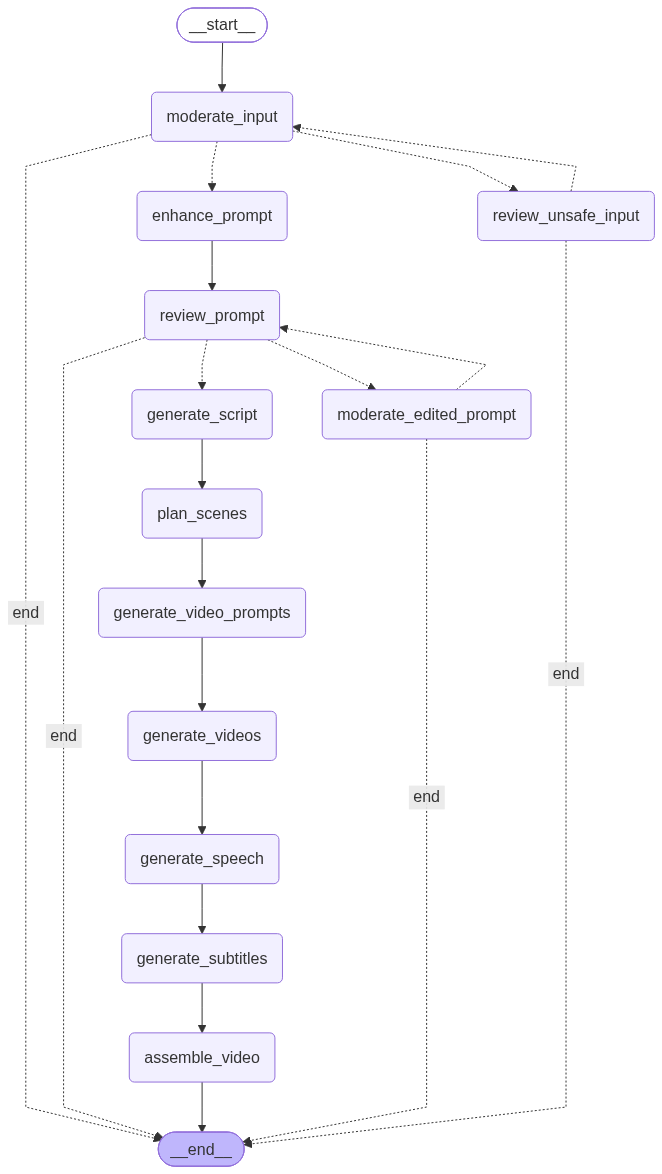

In [76]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 11. End-to-End Test

### 11.1 Run Until Human Review

In [77]:
checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)

In [78]:
config = {
    "configurable": {
        "thread_id": "agentic-video-test-1"
    }
}

In [79]:
initial_state: VideoState = {
    "user_prompt": (
        "Create an approximately 1-minute introduction video about AgenticVideo. "
        "AgenticVideo is an AI-powered system that can turn a user's idea into a complete video. "
        "Introduce what AgenticVideo is, show how a simple idea can be transformed into engaging "
        "video content, and highlight how AI helps with planning, creating visuals, narration, "
        "subtitles, and producing the final video. "
        "Keep the explanation simple and accessible to a general audience. "
        "Avoid detailed technical explanations, programming terminology, code, architecture diagrams, "
        "or complex system diagrams. "
        "Use visually interesting real-world scenes and cinematic technology-inspired imagery. "
        "The video should feel modern, polished, engaging, and professional."
    ),

    "required_words": [
        "AgenticVideo",
        "AI"
    ],

    "reference_image": None,
    "moderation_retry_count": 0
}

In [80]:
response = graph.invoke(initial_state, config = config)

In [81]:
# Inspect the interrupt
pprint(response["__interrupt__"][0].value)

{'enhanced_prompt': {'audience': 'General audience: creators, small business '
                                 'owners, marketers, educators, and curious '
                                 'non-technical users who want an easy way to '
                                 'turn ideas into videos.',
                     'duration_seconds': 60,
                     'key_message': 'AgenticVideo uses AI to turn a simple '
                                    'idea into a complete, engaging video by '
                                    'handling planning, visuals, narration, '
                                    'subtitles, and final production — making '
                                    'professional video creation fast and '
                                    'accessible.',
                     'objective': 'Introduce AgenticVideo and show, in a '
                                  "simple and accessible way, how a user's "
                                  'basic idea is transformed into

### 11.2 Approve and Run to Completion

In [82]:
# PAID API CALL
response = graph.invoke(Command(resume = {"action": "approve"}), config = config)

Deserializing unregistered type __main__.EnhancedPrompt from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'EnhancedPrompt')]



Scene 1/9


/var/folders/kw/xjs_s57d66dc3cnb0p3gwv180000gn/T/ipykernel_69820/2256198053.py:4: DeprecationWarning: The generate_videos method with prompt/image/video arguments is deprecated and will be removed in a future major release (not before 2026-07-31). Please use the source argument instead.
  return client.models.generate_videos(model = VIDEO_MODEL,


Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...

Scene 2/9
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...

Scene 3/9
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...

Scene 4/9
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...

Scene 5/9
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...

Scene 6/9
Video is still generating...
Video is still generating...
Video is still generating...
Video is still generating...

Scene 7/9
Video is still generating...
Video 

### 11.3 Inspect Results

In [83]:
print("=== SCRIPT ===")
print(response["script"].title)

print(f"\n=== SCENES: {len(response['scenes'])} ===")
print(f"=== VIDEO PROMPTS: {len(response['video_prompts'])} ===")

print("\n=== VIDEO GENERATION ===")
if not response["generation_results"]:
    print("Skipped (RUN_VIDEO_GENERATION = False)")

for result in response["generation_results"]:
    print(f"Scene {result.scene_id}: {result.status.value}", result.video_path or result.error_message)

print("\n=== SPEECH ===")
print(f"Audio: {Path(response['speech_result'].audio_path).resolve()}")
print(f"Duration: {response['speech_result'].duration_seconds:.2f} seconds")

print("\n=== SUBTITLES ===")
print(f"SRT file: {Path(response['subtitle_result'].subtitle_path).resolve()}")
print(f"Segments: {len(response['subtitle_result'].segments)}")

print("\n=== FINAL VIDEO ===")
if "final_video" in response:
    print(f"Video: {Path(response['final_video'].video_path).resolve()}")
    print(f"Duration: {response['final_video'].duration_seconds:.2f} seconds")
else:
    print("Skipped (no completed scene videos)")

=== SCRIPT ===
AgenticVideo: Idea to Video

=== SCENES: 9 ===
=== VIDEO PROMPTS: 9 ===

=== VIDEO GENERATION ===
Scene 1: completed ../outputs/video_generation/videos/scene_001.mp4
Scene 2: completed ../outputs/video_generation/videos/scene_002.mp4
Scene 3: completed ../outputs/video_generation/videos/scene_003.mp4
Scene 4: completed ../outputs/video_generation/videos/scene_004.mp4
Scene 5: completed ../outputs/video_generation/videos/scene_005.mp4
Scene 6: completed ../outputs/video_generation/videos/scene_006.mp4
Scene 7: completed ../outputs/video_generation/videos/scene_007.mp4
Scene 8: completed ../outputs/video_generation/videos/scene_008.mp4
Scene 9: completed ../outputs/video_generation/videos/scene_009.mp4

=== SPEECH ===
Audio: /Users/yukpinglee/Desktop/agentic-video/outputs/speech_generation/audio/narration.mp3
Duration: 61.70 seconds

=== SUBTITLES ===
SRT file: /Users/yukpinglee/Desktop/agentic-video/outputs/subtitles/subtitles.srt
Segments: 22

=== FINAL VIDEO ===
Video: 